#  Machine Learning Assignment 2
**Instructor:** Ibrahim O. Kaware

---

##  Student Information


**Name:** Falastine Abu Serrya  
**University ID:** 2320222142

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Regression
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

# Classification
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Clustering
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

## Loading Dataset
The dataset is loaded and inspected for structure, missing values, and basic statistics.

In [ ]:
df = pd.read_csv("marketing_campaign.csv", sep='\t')

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
print(df.shape)

df.info()

df.describe()

(2240, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 n

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


## Handling Missing Values

The Income column contains missing values. Median imputation is used because it is robust against outliers.

In [ ]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [ ]:
df["Income"] = df["Income"].fillna(df["Income"].median())

## Feature Engineering

Three new features were created:

1. Age
2. TotalSpending
3. TotalChildren

In [ ]:
current_year = 2026

df["Age"] = current_year - df["Year_Birth"]

In [ ]:
df["TotalSpending"] = (
    df["MntWines"]
    + df["MntFruits"]
    + df["MntMeatProducts"]
    + df["MntFishProducts"]
    + df["MntSweetProducts"]
    + df["MntGoldProds"]
)

In [ ]:
df["TotalChildren"] = df["Kidhome"] + df["Teenhome"]

## Removing Unrealistic Values

Customers with unrealistic ages and zero income are removed.

In [ ]:
df = df[(df["Age"] >= 18) & (df["Age"] <= 100)]

df = df[df["Income"] > 0]

## Encoding Categorical Variables

In [ ]:
education_map = {
    "Basic":0,
    "Graduation":1,
    "2n Cycle":1,
    "Master":2,
    "PhD":3
}

df["Education"] = df["Education"].map(education_map)

In [ ]:
top4 = df["Marital_Status"].value_counts().nlargest(4).index

df["Marital_Status"] = df["Marital_Status"].apply(
    lambda x: x if x in top4 else "Other"
)

In [ ]:
df = pd.get_dummies(
    df,
    columns=["Marital_Status"],
    drop_first=True
)

## Exploratory Data Analysis

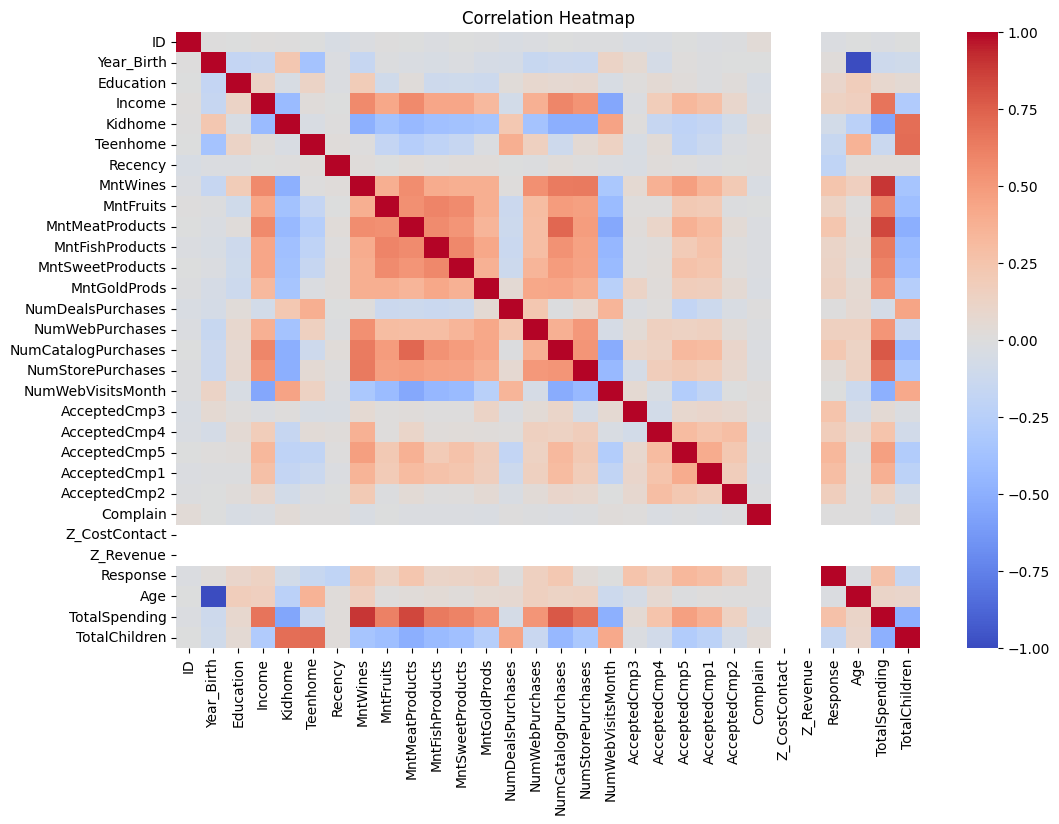

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

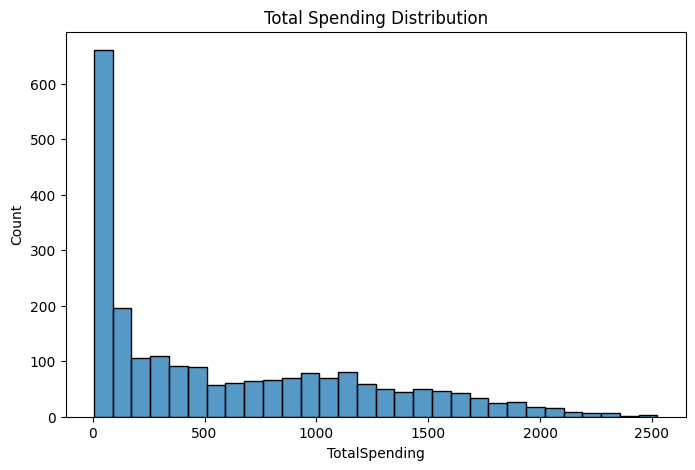

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["TotalSpending"], bins=30)

plt.title("Total Spending Distribution")

plt.show()

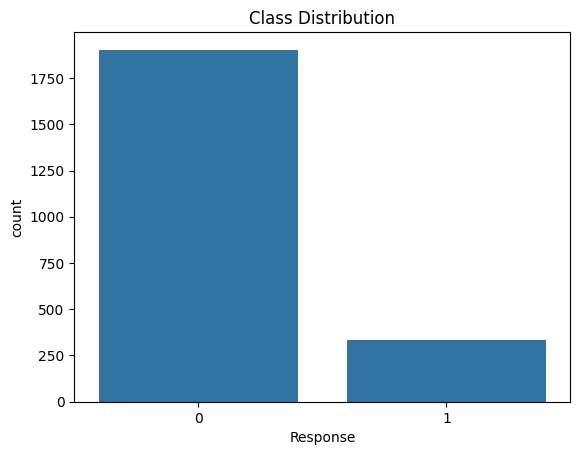

In [ ]:
sns.countplot(x="Response", data=df)

plt.title("Class Distribution")

plt.show()

In [ ]:
print(df["Response"].value_counts())

Response
0    1903
1     334
Name: count, dtype: int64


# Regression Task

Target Variable:
TotalSpending

Features

In [ ]:
X_reg = df.drop(
    columns=["TotalSpending","ID"]
)

X_reg = X_reg.select_dtypes(include=np.number)

y_reg = df["TotalSpending"]

Split Data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

Scaling

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

Linear Regression

In [ ]:
lr = LinearRegression()

lr.fit(X_train_scaled,y_train)

pred_lr = lr.predict(X_test_scaled)

Ridge Regression

In [ ]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled,y_train)

pred_ridge = ridge.predict(X_test_scaled)

Decision Tree

In [ ]:
tree = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

tree.fit(X_train_scaled,y_train)

pred_tree = tree.predict(X_test_scaled)

Evaluation

In [ ]:
results = []

models = {
    "Linear Regression":pred_lr,
    "Ridge Regression":pred_ridge,
    "Decision Tree":pred_tree
}

for name,pred in models.items():

    mse = mean_squared_error(y_test,pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test,pred)

    results.append([name,mse,rmse,r2])

results_df = pd.DataFrame(
    results,
    columns=["Model","MSE","RMSE","R2"]
)

results_df

,Model,MSE,RMSE,R2
0,Linear Regression,1.127247e-24,1.061719e-12,1.000000
1,Ridge Regression,1.645649e-01,4.056660e-01,1.000000
2,Decision Tree,1.626342e+04,1.275281e+02,0.957187


# Classification Task

Target Variable:
Response

Features

In [ ]:
X_cls = df.drop(columns=["Response","ID"])

X_cls = X_cls.select_dtypes(include=np.number)

y_cls = df["Response"]

Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_cls,
    y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

Scaling

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

Logistic Regression

In [ ]:
log_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

log_model.fit(X_train_scaled,y_train)

pred_log = log_model.predict(X_test_scaled)

KNN

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled,y_train)

pred_knn = knn.predict(X_test_scaled)

Random Forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

Evaluation Function

In [ ]:
def evaluate(y_true,y_pred,name):

    print(name)

    print(classification_report(
        y_true,
        y_pred
    ))

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt='d'
    )

    plt.title(name)

    plt.show()

Logistic Regression
              precision    recall  f1-score   support

           0       0.95      0.82      0.88       381
           1       0.44      0.78      0.56        67

    accuracy                           0.82       448
   macro avg       0.70      0.80      0.72       448
weighted avg       0.88      0.82      0.84       448



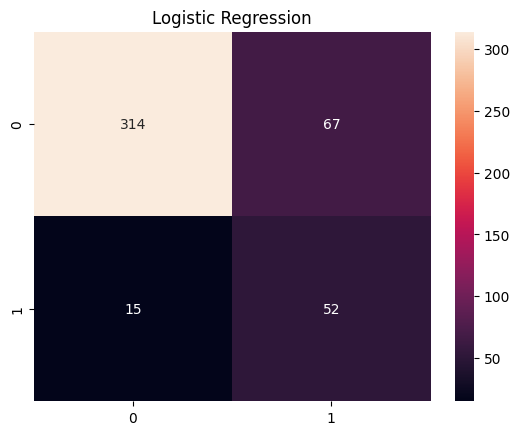

In [ ]:
evaluate(y_test,pred_log,"Logistic Regression")

KNN
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       381
           1       0.58      0.31      0.41        67

    accuracy                           0.86       448
   macro avg       0.74      0.64      0.67       448
weighted avg       0.84      0.86      0.85       448



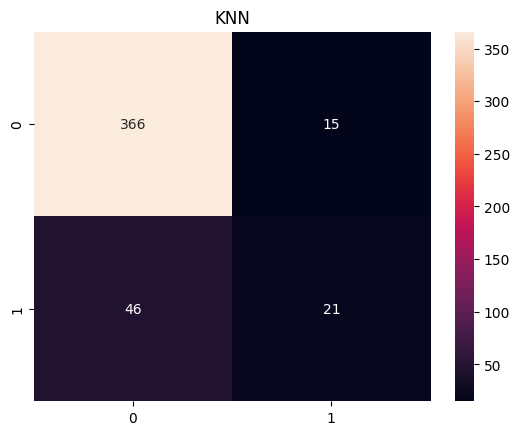

In [ ]:
evaluate(y_test,pred_knn,"KNN")

Random Forest
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       381
           1       0.71      0.30      0.42        67

    accuracy                           0.88       448
   macro avg       0.80      0.64      0.68       448
weighted avg       0.86      0.88      0.86       448



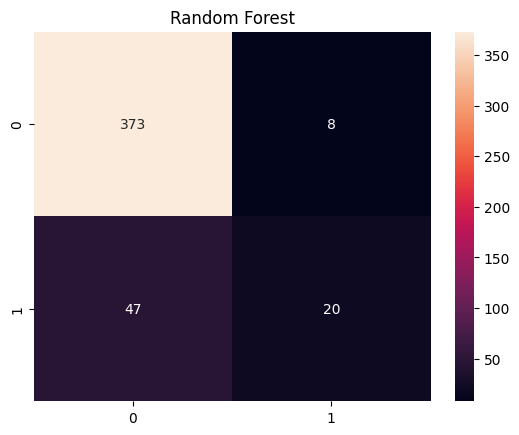

In [ ]:
evaluate(y_test,pred_rf,"Random Forest")

### Why is F1-Score Important?

The dataset is imbalanced because most customers did not accept the marketing campaign.

Therefore, F1-Score is more informative than Accuracy because it balances Precision and Recall.

# Clustering

# Customer Segmentation using K-Means

Select Features

In [ ]:
cluster_features = df[
    [
        "TotalSpending",
        "Income",
        "Age",
        "TotalChildren"
    ]
]

Scaling

In [ ]:
scaler = StandardScaler()

scaled = scaler.fit_transform(
    cluster_features
)

Elbow Method

In [ ]:
inertia = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(scaled)

    inertia.append(model.inertia_)

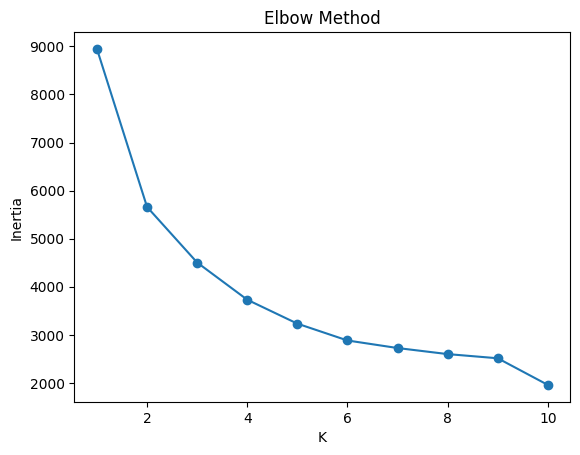

In [ ]:
plt.plot(range(1,11), inertia, marker='o')

plt.xlabel("K")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

Choose K = 3

The elbow curve suggests that K=3 is a reasonable choice because the reduction in inertia starts to slow significantly after this point.

Train KMeans

In [ ]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

df["Cluster"] = kmeans.fit_predict(
    scaled
)

PCA Visualization

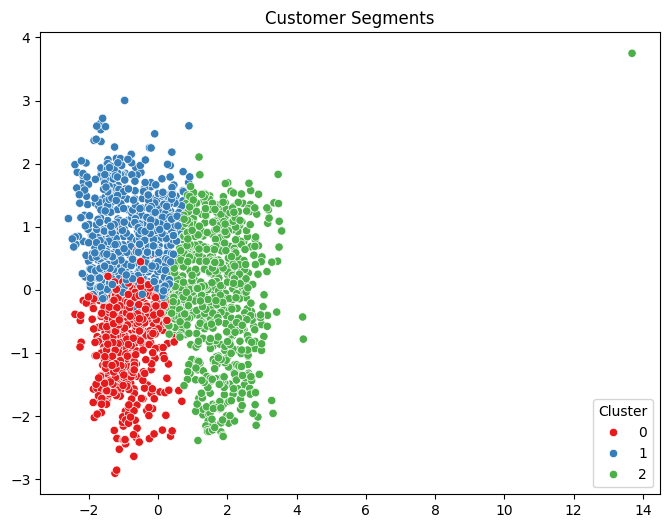

In [ ]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(
    scaled
)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pca_data[:,0],
    y=pca_data[:,1],
    hue=df["Cluster"],
    palette="Set1"
)

plt.title("Customer Segments")

plt.show()

Cluster Profiling

In [ ]:
cluster_profile = df.groupby(
    "Cluster"
)[
[
    "Income",
    "TotalSpending",
    "Age",
    "TotalChildren"
]
].mean()

cluster_profile

,Income,TotalSpending,Age,TotalChildren
Cluster,,,,
0,33235.539295,161.471545,48.714092,0.853659
1,47763.638239,314.640990,64.181568,1.660248
2,74586.422280,1304.582902,58.443005,0.375648


# Conclusion

1. Regression models were used to predict customer spending.
2. Classification models predicted campaign acceptance.
3. Random Forest achieved the best classification performance.
4. K-Means successfully segmented customers into distinct groups.
5. Customer segmentation can support targeted marketing strategies.